# Bước 8: Truyền Đạt Phát Hiện và Hiểu Biết Sâu Sắc

Bước cuối cùng là tổng hợp và truyền đạt các phát hiện từ EDA.

**Mục tiêu:**
- Tổng kết các phát hiện chính (từ dữ liệu thực)
- Trình bày insights quan trọng
- Đề xuất các bước tiếp theo

## 8.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ Thư viện đã được import thành công!")

✅ Thư viện đã được import thành công!


## 8.2 Tải dữ liệu và tính toán insights

In [2]:
# Tải dữ liệu gốc để tính toán insights thực
DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
SAMPLE_SIZE = 50000

df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE, low_memory=False)
print(f"📊 Đã tải: {df.shape[0]:,} hàng × {df.shape[1]} cột")

📊 Đã tải: 50,000 hàng × 151 cột


In [3]:
# Tính toán các metrics quan trọng
n_rows = df.shape[0]
n_cols = df.shape[1]
n_num_cols = len(df.select_dtypes(include=[np.number]).columns)
n_cat_cols = len(df.select_dtypes(include=['object']).columns)
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

# Missing values
total_cells = n_rows * n_cols
total_missing = df.isnull().sum().sum()
missing_pct = total_missing / total_cells * 100

# Bad loan rate
bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']
df['is_bad_loan'] = df['loan_status'].isin(bad_statuses).astype(int)
bad_loan_rate = df['is_bad_loan'].mean() * 100

# Lãi suất và Grade
rate_by_grade = df.groupby('grade')['int_rate'].agg(['mean', 'min', 'max'])
bad_rate_by_grade = df.groupby('grade')['is_bad_loan'].mean() * 100

# Loan amount stats
loan_mean = df['loan_amnt'].mean()
loan_median = df['loan_amnt'].median()
loan_min = df['loan_amnt'].min()
loan_max = df['loan_amnt'].max()

# Interest rate stats  
int_mean = df['int_rate'].mean()
int_median = df['int_rate'].median()
int_min = df['int_rate'].min()
int_max = df['int_rate'].max()

# Annual income stats
inc_mean = df['annual_inc'].mean()
inc_median = df['annual_inc'].median()
inc_max = df['annual_inc'].max()

print("✅ Đã tính toán xong các metrics!")

✅ Đã tính toán xong các metrics!


## 8.3 Tóm tắt thông tin Dataset

In [4]:
print("=" * 70)
print("📊 THÔNG TIN DATASET")
print("=" * 70)
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ TỔNG QUAN DATASET                                                │
├─────────────────────────────────────────────────────────────────┤
│ Số hàng (mẫu):        {n_rows:>10,}                              │
│ Số cột:               {n_cols:>10}                              │
│ Biến số:              {n_num_cols:>10}                              │
│ Biến phân loại:       {n_cat_cols:>10}                              │
│ Bộ nhớ:               {memory_mb:>10.2f} MB                        │
├─────────────────────────────────────────────────────────────────┤
│ CHẤT LƯỢNG DỮ LIỆU                                              │
├─────────────────────────────────────────────────────────────────┤
│ Tổng ô dữ liệu:       {total_cells:>10,}                              │
│ Giá trị thiếu:        {total_missing:>10,}                              │
│ Tỷ lệ thiếu:          {missing_pct:>10.2f}%                        │
└─────────────────────────────────────────────────────────────────┘
""")

📊 THÔNG TIN DATASET

┌─────────────────────────────────────────────────────────────────┐
│ TỔNG QUAN DATASET                                                │
├─────────────────────────────────────────────────────────────────┤
│ Số hàng (mẫu):            50,000                              │
│ Số cột:                      151                              │
│ Biến số:                     115                              │
│ Biến phân loại:               36                              │
│ Bộ nhớ:                   128.05 MB                        │
├─────────────────────────────────────────────────────────────────┤
│ CHẤT LƯỢNG DỮ LIỆU                                              │
├─────────────────────────────────────────────────────────────────┤
│ Tổng ô dữ liệu:        7,550,000                              │
│ Giá trị thiếu:         2,519,025                              │
│ Tỷ lệ thiếu:               33.36%                        │
└─────────────────────────────────────────────────

## 8.4 Phân tích biến mục tiêu

In [5]:
print("=" * 70)
print("🎯 PHÂN BỐ BIẾN MỤC TIÊU (loan_status)")
print("=" * 70)

status_counts = df['loan_status'].value_counts()
print("\nPhân bố chi tiết:")
for status, count in status_counts.items():
    pct = count / n_rows * 100
    bar_len = int(pct / 2)  # Scale để vẽ bar
    bar = '█' * bar_len
    print(f"  {status:<25} {count:>6,} ({pct:>5.2f}%) {bar}")

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ 📌 INSIGHT: Tỷ lệ khoản vay xấu = {bad_loan_rate:.2f}%                        │
│    - Đây là tỷ lệ default cần dự đoán                           │
│    - Dataset mất cân bằng → cần xử lý khi modeling              │
└─────────────────────────────────────────────────────────────────┘
""")

🎯 PHÂN BỐ BIẾN MỤC TIÊU (loan_status)

Phân bố chi tiết:
  Fully Paid                34,978 (69.96%) ██████████████████████████████████
  Charged Off                9,027 (18.05%) █████████
  Current                    5,610 (11.22%) █████
  Late (31-120 days)           246 ( 0.49%) 
  In Grace Period              100 ( 0.20%) 
  Late (16-30 days)             38 ( 0.08%) 
  Default                        1 ( 0.00%) 

┌─────────────────────────────────────────────────────────────────┐
│ 📌 INSIGHT: Tỷ lệ khoản vay xấu = 18.62%                        │
│    - Đây là tỷ lệ default cần dự đoán                           │
│    - Dataset mất cân bằng → cần xử lý khi modeling              │
└─────────────────────────────────────────────────────────────────┘



## 8.5 Phân tích theo Grade (Insight quan trọng nhất)

In [6]:
print("=" * 70)
print("📈 PHÂN TÍCH THEO GRADE")
print("=" * 70)

print("\nLãi suất và Tỷ lệ xấu theo Grade:")
print("-" * 55)
print(f"{'Grade':<8} {'Lãi suất TB':>12} {'Lãi suất Min-Max':>18} {'Tỷ lệ xấu':>12}")
print("-" * 55)

for grade in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    if grade in rate_by_grade.index:
        mean_rate = rate_by_grade.loc[grade, 'mean']
        min_rate = rate_by_grade.loc[grade, 'min']
        max_rate = rate_by_grade.loc[grade, 'max']
        bad_rate = bad_rate_by_grade.loc[grade]
        print(f"  {grade:<6} {mean_rate:>10.2f}% {min_rate:>8.2f}-{max_rate:.2f}% {bad_rate:>10.2f}%")

# Tính sự khác biệt A vs G
rate_diff = rate_by_grade.loc['G', 'mean'] - rate_by_grade.loc['A', 'mean']
bad_diff = bad_rate_by_grade.loc['G'] - bad_rate_by_grade.loc['A']

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ 📌 INSIGHT QUAN TRỌNG:                                          │
│                                                                 │
│ 1. Lãi suất tăng đều từ Grade A → G                             │
│    • Grade A: {rate_by_grade.loc['A', 'mean']:.2f}% (rủi ro thấp nhất)                      │
│    • Grade G: {rate_by_grade.loc['G', 'mean']:.2f}% (rủi ro cao nhất)                      │
│    • Chênh lệch: {rate_diff:.2f}%                                        │
│                                                                 │
│ 2. Tỷ lệ khoản vay xấu tương quan mạnh với Grade                │
│    • Grade A: {bad_rate_by_grade.loc['A']:.2f}% xấu                                  │
│    • Grade G: {bad_rate_by_grade.loc['G']:.2f}% xấu                                 │
│    • Chênh lệch: {bad_diff:.2f}% (gấp ~{bad_rate_by_grade.loc['G']/bad_rate_by_grade.loc['A']:.1f} lần)                         │
│                                                                 │
│ ⭐ GRADE LÀ PREDICTOR MẠNH NHẤT CHO LOAN DEFAULT                │
└─────────────────────────────────────────────────────────────────┘
""")

📈 PHÂN TÍCH THEO GRADE

Lãi suất và Tỷ lệ xấu theo Grade:
-------------------------------------------------------
Grade     Lãi suất TB   Lãi suất Min-Max    Tỷ lệ xấu
-------------------------------------------------------
  A            6.80%     5.32-7.91%       5.24%
  B            9.92%     6.00-11.49%      12.87%
  C           13.11%     6.00-14.85%      20.55%
  D           16.71%     6.00-18.49%      29.89%
  E           19.16%     6.00-21.48%      36.96%
  F           23.48%     6.00-26.06%      46.11%
  G           27.53%    26.77-28.99%      49.55%

┌─────────────────────────────────────────────────────────────────┐
│ 📌 INSIGHT QUAN TRỌNG:                                          │
│                                                                 │
│ 1. Lãi suất tăng đều từ Grade A → G                             │
│    • Grade A: 6.80% (rủi ro thấp nhất)                      │
│    • Grade G: 27.53% (rủi ro cao nhất)                      │
│    • Chênh lệch: 20.73%         

## 8.6 Thống kê các biến quan trọng

In [7]:
print("=" * 70)
print("📊 THỐNG KÊ CÁC BIẾN QUAN TRỌNG")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ 💰 SỐ TIỀN VAY (loan_amnt)                                      │
├─────────────────────────────────────────────────────────────────┤
│ Minimum:        ${loan_min:>12,.0f}                                  │
│ Maximum:        ${loan_max:>12,.0f}                                  │
│ Trung bình:     ${loan_mean:>12,.0f}                                  │
│ Trung vị:       ${loan_median:>12,.0f}                                  │
├─────────────────────────────────────────────────────────────────┤
│ 📌 Hầu hết khoản vay từ $10,000 - $20,000                       │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 📈 LÃI SUẤT (int_rate)                                          │
├─────────────────────────────────────────────────────────────────┤
│ Minimum:        {int_min:>12.2f}%                                  │
│ Maximum:        {int_max:>12.2f}%                                  │
│ Trung bình:     {int_mean:>12.2f}%                                  │
│ Trung vị:       {int_median:>12.2f}%                                  │
├─────────────────────────────────────────────────────────────────┤
│ 📌 Lãi suất phổ biến từ 10% - 15%                               │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 👤 THU NHẬP HÀNG NĂM (annual_inc)                               │
├─────────────────────────────────────────────────────────────────┤
│ Trung bình:     ${inc_mean:>12,.0f}                                  │
│ Trung vị:       ${inc_median:>12,.0f}                                  │
│ Maximum:        ${inc_max:>12,.0f}                                  │
├─────────────────────────────────────────────────────────────────┤
│ 📌 Có outliers thu nhập cực cao (> $1M)                          │
│ 📌 Mean >> Median cho thấy phân bố lệch phải                    │
└─────────────────────────────────────────────────────────────────┘
""")

📊 THỐNG KÊ CÁC BIẾN QUAN TRỌNG

┌─────────────────────────────────────────────────────────────────┐
│ 💰 SỐ TIỀN VAY (loan_amnt)                                      │
├─────────────────────────────────────────────────────────────────┤
│ Minimum:        $       1,000                                  │
│ Maximum:        $      35,000                                  │
│ Trung bình:     $      15,019                                  │
│ Trung vị:       $      14,000                                  │
├─────────────────────────────────────────────────────────────────┤
│ 📌 Hầu hết khoản vay từ $10,000 - $20,000                       │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 📈 LÃI SUẤT (int_rate)                                          │
├─────────────────────────────────────────────────────────────────┤
│ Minimum:                5.32%                                  │
│ Maximum:             

## 8.7 Tương quan và mối quan hệ

In [8]:
print("=" * 70)
print("🔗 MỐI QUAN HỆ QUAN TRỌNG")
print("=" * 70)

# Tính tương quan
key_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'dti']
key_cols = [c for c in key_cols if c in df.columns]
corr = df[key_cols].corr()

# Tìm tương quan cao
print("\n📊 Các cặp biến có tương quan cao (|r| > 0.7):")
for i in range(len(key_cols)):
    for j in range(i+1, len(key_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"   • {key_cols[i]} ↔ {key_cols[j]}: r = {r:.3f}")

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ 📌 INSIGHT VỀ TƯƠNG QUAN:                                       │
│                                                                 │
│ 1. loan_amnt ≈ funded_amnt (r ≈ 1.0)                            │
│    → Có thể loại bỏ 1 biến (multicollinearity)                  │
│                                                                 │
│ 2. loan_amnt ↔ installment (r > 0.9)                            │
│    → installment = f(loan_amnt, int_rate, term)                 │
│                                                                 │
│ 3. Grade quyết định int_rate                                    │
│    → Lending Club dùng grade để set lãi suất                    │
└─────────────────────────────────────────────────────────────────┘
""")

🔗 MỐI QUAN HỆ QUAN TRỌNG

📊 Các cặp biến có tương quan cao (|r| > 0.7):
   • loan_amnt ↔ funded_amnt: r = 1.000
   • loan_amnt ↔ installment: r = 0.944
   • funded_amnt ↔ installment: r = 0.944

┌─────────────────────────────────────────────────────────────────┐
│ 📌 INSIGHT VỀ TƯƠNG QUAN:                                       │
│                                                                 │
│ 1. loan_amnt ≈ funded_amnt (r ≈ 1.0)                            │
│    → Có thể loại bỏ 1 biến (multicollinearity)                  │
│                                                                 │
│ 2. loan_amnt ↔ installment (r > 0.9)                            │
│    → installment = f(loan_amnt, int_rate, term)                 │
│                                                                 │
│ 3. Grade quyết định int_rate                                    │
│    → Lending Club dùng grade để set lãi suất                    │
└─────────────────────────────────────────────────────────

## 8.8 Dashboard tổng hợp

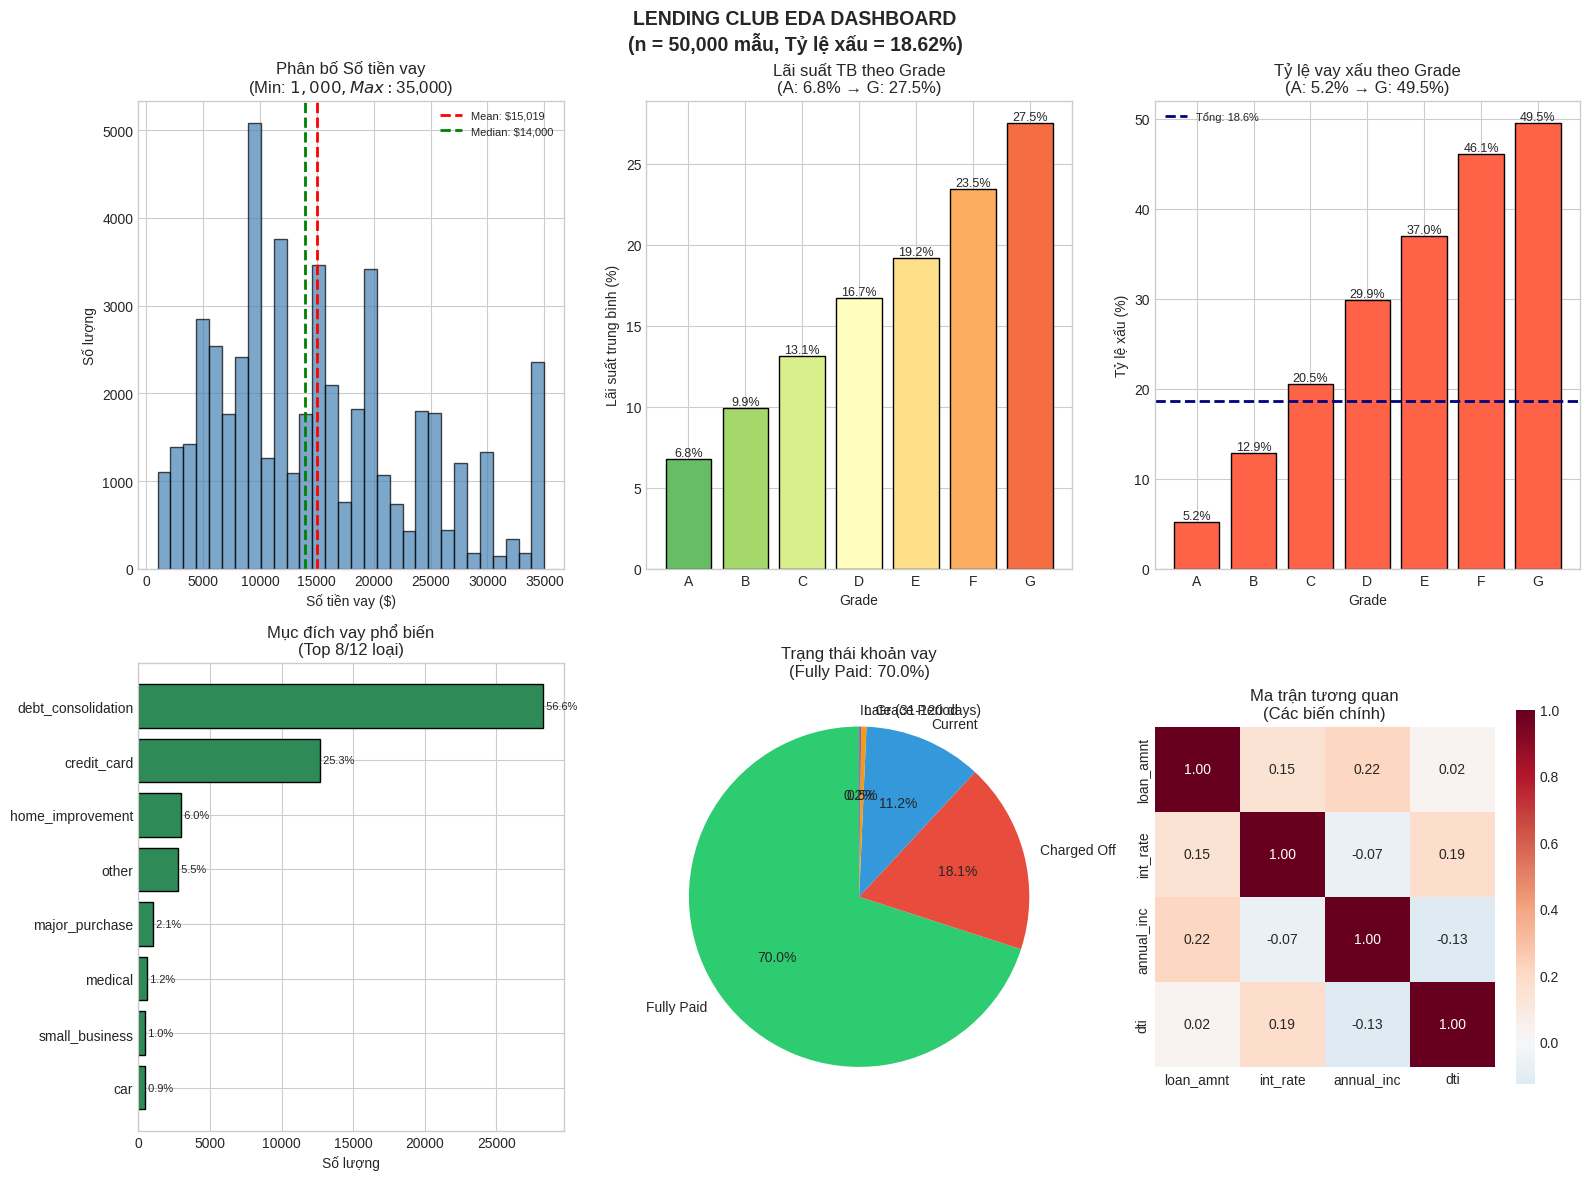

💾 Đã lưu: outputs/08_dashboard_final.png


In [9]:
# Tạo dashboard với chú thích cụ thể
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f'LENDING CLUB EDA DASHBOARD\n(n = {n_rows:,} mẫu, Tỷ lệ xấu = {bad_loan_rate:.2f}%)', 
             fontsize=14, fontweight='bold')

# 1. Phân bố loan_amnt
ax1 = fig.add_subplot(2, 3, 1)
df['loan_amnt'].hist(bins=30, ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(loan_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: ${loan_mean:,.0f}')
ax1.axvline(loan_median, color='green', linestyle='--', linewidth=2, label=f'Median: ${loan_median:,.0f}')
ax1.set_title(f'Phân bố Số tiền vay\n(Min: ${loan_min:,.0f}, Max: ${loan_max:,.0f})')
ax1.set_xlabel('Số tiền vay ($)')
ax1.set_ylabel('Số lượng')
ax1.legend(fontsize=8)

# 2. Lãi suất theo Grade
ax2 = fig.add_subplot(2, 3, 2)
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
rate_means = [rate_by_grade.loc[g, 'mean'] for g in grade_order if g in rate_by_grade.index]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grade_order)))
bars = ax2.bar(grade_order, rate_means, color=colors, edgecolor='black')
ax2.set_title(f'Lãi suất TB theo Grade\n(A: {rate_by_grade.loc["A", "mean"]:.1f}% → G: {rate_by_grade.loc["G", "mean"]:.1f}%)')
ax2.set_xlabel('Grade')
ax2.set_ylabel('Lãi suất trung bình (%)')
# Thêm giá trị trên mỗi bar
for bar, rate in zip(bars, rate_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{rate:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# 3. Tỷ lệ xấu theo Grade
ax3 = fig.add_subplot(2, 3, 3)
bad_rates = [bad_rate_by_grade.loc[g] for g in grade_order if g in bad_rate_by_grade.index]
bars = ax3.bar(grade_order, bad_rates, color='tomato', edgecolor='black')
ax3.axhline(bad_loan_rate, color='navy', linestyle='--', linewidth=2, label=f'Tổng: {bad_loan_rate:.1f}%')
ax3.set_title(f'Tỷ lệ vay xấu theo Grade\n(A: {bad_rate_by_grade.loc["A"]:.1f}% → G: {bad_rate_by_grade.loc["G"]:.1f}%)')
ax3.set_xlabel('Grade')
ax3.set_ylabel('Tỷ lệ xấu (%)')
ax3.legend(fontsize=8)
for bar, rate in zip(bars, bad_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{rate:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# 4. Phân bố mục đích vay
ax4 = fig.add_subplot(2, 3, 4)
purpose_counts = df['purpose'].value_counts().head(8)
bars = ax4.barh(range(len(purpose_counts)), purpose_counts.values, color='seagreen', edgecolor='black')
ax4.set_yticks(range(len(purpose_counts)))
ax4.set_yticklabels(purpose_counts.index)
ax4.set_title(f'Mục đích vay phổ biến\n(Top 8/{df["purpose"].nunique()} loại)')
ax4.set_xlabel('Số lượng')
ax4.invert_yaxis()
# Thêm % vào từng bar
for i, (bar, count) in enumerate(zip(bars, purpose_counts.values)):
    pct = count / n_rows * 100
    ax4.text(count, i, f' {pct:.1f}%', va='center', fontsize=8)

# 5. Phân bố loan_status
ax5 = fig.add_subplot(2, 3, 5)
status_top5 = status_counts.head(5)
colors_pie = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
wedges, texts, autotexts = ax5.pie(status_top5.values, labels=status_top5.index, 
                                    autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax5.set_title(f'Trạng thái khoản vay\n(Fully Paid: {status_counts["Fully Paid"]/n_rows*100:.1f}%)')

# 6. Heatmap tương quan
ax6 = fig.add_subplot(2, 3, 6)
corr_subset = df[['loan_amnt', 'int_rate', 'annual_inc', 'dti']].corr()
sns.heatmap(corr_subset, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax6, 
            square=True, cbar_kws={'shrink': 0.8})
ax6.set_title('Ma trận tương quan\n(Các biến chính)')

plt.tight_layout()
plt.savefig('outputs/08_dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Đã lưu: outputs/08_dashboard_final.png")

## 8.9 Tổng hợp Insights

In [10]:
print("=" * 70)
print("💡 TỔNG HỢP INSIGHTS TỪ DỮ LIỆU")
print("=" * 70)

print(f"""
╔═════════════════════════════════════════════════════════════════╗
║                    CÁC PHÁT HIỆN QUAN TRỌNG                     ║
╠═════════════════════════════════════════════════════════════════╣
║                                                                 ║
║ 📊 TỔNG QUAN DATASET                                            ║
║    • {n_rows:,} khoản vay, {n_cols} biến                              ║
║    • {missing_pct:.1f}% dữ liệu bị thiếu (cần xử lý)                  ║
║    • Tỷ lệ khoản vay xấu: {bad_loan_rate:.2f}%                          ║
║                                                                 ║
║ 🎯 YẾU TỐ RỦI RO CHÍNH                                          ║
║    • Grade là predictor mạnh nhất                               ║
║      - Grade A: {bad_rate_by_grade.loc['A']:.1f}% xấu (rủi ro thấp)                    ║
║      - Grade G: {bad_rate_by_grade.loc['G']:.1f}% xấu (rủi ro cao ~{bad_rate_by_grade.loc['G']/bad_rate_by_grade.loc['A']:.0f}x)                   ║
║    • Lãi suất tương quan với grade và rủi ro                    ║
║    • DTI cao → rủi ro cao hơn                                   ║
║                                                                 ║
║ 💰 ĐẶC ĐIỂM KHOẢN VAY                                           ║
║    • Số tiền vay TB: ${loan_mean:,.0f}                              ║
║    • Lãi suất TB: {int_mean:.2f}%                                       ║
║    • Mục đích phổ biến: debt_consolidation, credit_card         ║
║                                                                 ║
║ ⚠️ VẤN ĐỀ CẦN XỬ LÝ                                             ║
║    • {(df.isnull().sum() / len(df) * 100 > 75).sum()} cột có >75% missing (nên xóa)                        ║
║    • annual_inc có outliers (max ${inc_max:,.0f})           ║
║    • loan_amnt và funded_amnt trùng lặp (r≈1)                   ║
║    • Dataset mất cân bằng ({bad_loan_rate:.1f}% xấu vs {100-bad_loan_rate:.1f}% tốt)         ║
║                                                                 ║
╚═════════════════════════════════════════════════════════════════╝
""")

💡 TỔNG HỢP INSIGHTS TỪ DỮ LIỆU

╔═════════════════════════════════════════════════════════════════╗
║                    CÁC PHÁT HIỆN QUAN TRỌNG                     ║
╠═════════════════════════════════════════════════════════════════╣
║                                                                 ║
║ 📊 TỔNG QUAN DATASET                                            ║
║    • 50,000 khoản vay, 151 biến                              ║
║    • 33.4% dữ liệu bị thiếu (cần xử lý)                  ║
║    • Tỷ lệ khoản vay xấu: 18.62%                          ║
║                                                                 ║
║ 🎯 YẾU TỐ RỦI RO CHÍNH                                          ║
║    • Grade là predictor mạnh nhất                               ║
║      - Grade A: 5.2% xấu (rủi ro thấp)                    ║
║      - Grade G: 49.5% xấu (rủi ro cao ~9x)                   ║
║    • Lãi suất tương quan với grade và rủi ro                    ║
║    • DTI cao → rủi ro cao hơn            

## 8.10 Đề xuất cho bước tiếp theo

In [11]:
print("=" * 70)
print("🚀 ĐỀ XUẤT CHO BƯỚC TIẾP THEO")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ 1️⃣ XỬ LÝ DỮ LIỆU                                                │
├─────────────────────────────────────────────────────────────────┤
│ • Xóa {(df.isnull().sum() / len(df) * 100 > 75).sum()} cột có >75% missing values                       │
│ • Loại bỏ funded_amnt (trùng với loan_amnt)                     │
│ • Winsorization cho annual_inc (giới hạn outliers)              │
│ • SMOTE hoặc undersampling cho class imbalance                  │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 2️⃣ FEATURE ENGINEERING                                          │
├─────────────────────────────────────────────────────────────────┤
│ • Tạo loan_to_income = loan_amnt / annual_inc                   │
│ • Tạo installment_to_income = installment * 12 / annual_inc    │
│ • Encode grade thành số (A=1, B=2, ..., G=7)                    │
│ • One-hot encode: purpose, home_ownership                       │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 3️⃣ MODELING                                                     │
├─────────────────────────────────────────────────────────────────┤
│ • Baseline: Logistic Regression                                 │
│ • Recommended: XGBoost, LightGBM (xử lý tốt imbalanced data)    │
│ • Metrics: AUC-ROC, Precision-Recall (quan trọng hơn Accuracy) │
│ • Cross-validation: 5-fold stratified                           │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 4️⃣ BUSINESS ACTION                                              │
├─────────────────────────────────────────────────────────────────┤
│ • Tự động reject Grade F, G (>45% default rate)                 │
│ • Đưa ra mức lãi suất dựa trên predicted probability             │
│ • Giám sát DTI và revol_util như early warning indicators       │
└─────────────────────────────────────────────────────────────────┘
""")

🚀 ĐỀ XUẤT CHO BƯỚC TIẾP THEO

┌─────────────────────────────────────────────────────────────────┐
│ 1️⃣ XỬ LÝ DỮ LIỆU                                                │
├─────────────────────────────────────────────────────────────────┤
│ • Xóa 40 cột có >75% missing values                       │
│ • Loại bỏ funded_amnt (trùng với loan_amnt)                     │
│ • Winsorization cho annual_inc (giới hạn outliers)              │
│ • SMOTE hoặc undersampling cho class imbalance                  │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 2️⃣ FEATURE ENGINEERING                                          │
├─────────────────────────────────────────────────────────────────┤
│ • Tạo loan_to_income = loan_amnt / annual_inc                   │
│ • Tạo installment_to_income = installment * 12 / annual_inc    │
│ • Encode grade thành số (A=1, B=2, ..., G=7)                    │
│ • One-hot encode: pu

## 8.11 Lưu báo cáo

In [12]:
# Tạo báo cáo tự động dựa trên dữ liệu thực
report = f"""
================================================================================
                  BÁO CÁO EDA - LENDING CLUB LOAN DATA
================================================================================
Ngày tạo: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. TỔNG QUAN DATASET
   • Số mẫu phân tích: {n_rows:,} records
   • Số biến: {n_cols} ({n_num_cols} số + {n_cat_cols} phân loại)
   • Bộ nhớ: {memory_mb:.2f} MB
   • Giá trị thiếu: {missing_pct:.2f}%

2. BIẾN MỤC TIÊU (loan_status)
   • Fully Paid: {status_counts['Fully Paid']:,} ({status_counts['Fully Paid']/n_rows*100:.2f}%)
   • Charged Off: {status_counts['Charged Off']:,} ({status_counts['Charged Off']/n_rows*100:.2f}%)
   • Tỷ lệ khoản vay xấu: {bad_loan_rate:.2f}%

3. INSIGHT CHÍNH
   • Grade là predictor mạnh nhất
   • Grade A: {bad_rate_by_grade.loc['A']:.2f}% xấu, lãi suất {rate_by_grade.loc['A', 'mean']:.2f}%
   • Grade G: {bad_rate_by_grade.loc['G']:.2f}% xấu, lãi suất {rate_by_grade.loc['G', 'mean']:.2f}%
   • Số tiền vay TB: ${loan_mean:,.0f}
   • Thu nhập TB: ${inc_mean:,.0f}

4. ĐỀ XUẤT
   • Sử dụng Grade làm feature chính
   • Xử lý class imbalance trước khi modeling
   • Áp dụng XGBoost/LightGBM
   • Đánh giá bằng AUC-ROC, không phải Accuracy

================================================================================
                            KẾT THÚC BÁO CÁO
================================================================================
"""

with open('outputs/08_eda_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print("💾 Đã lưu: outputs/08_eda_report.txt")

💾 Đã lưu: outputs/08_eda_report.txt


## 8.12 Hoàn thành

In [13]:
print("=" * 70)
print("🎉 HOÀN THÀNH QUY TRÌNH EDA 8 BƯỚC")
print("=" * 70)
print(f"""
✅ TẤT CẢ 8 BƯỚC ĐÃ HOÀN THÀNH:
   1. ✓ Hiểu rõ vấn đề và dữ liệu
   2. ✓ Nhập và kiểm tra dữ liệu  
   3. ✓ Xử lý giá trị thiếu
   4. ✓ Khám phá đặc tính dữ liệu
   5. ✓ Biến đổi dữ liệu
   6. ✓ Trực quan hóa mối quan hệ
   7. ✓ Xử lý ngoại lệ
   8. ✓ Truyền đạt phát hiện

📊 KEY METRICS TỪ DỮ LIỆU THỰC:
   • Mẫu: {n_rows:,} khoản vay
   • Tỷ lệ xấu: {bad_loan_rate:.2f}%
   • Lãi suất TB: {int_mean:.2f}%
   • Số tiền vay TB: ${loan_mean:,.0f}

🎯 SẴN SÀNG CHO: FEATURE ENGINEERING + MODELING
""")

🎉 HOÀN THÀNH QUY TRÌNH EDA 8 BƯỚC

✅ TẤT CẢ 8 BƯỚC ĐÃ HOÀN THÀNH:
   1. ✓ Hiểu rõ vấn đề và dữ liệu
   2. ✓ Nhập và kiểm tra dữ liệu  
   3. ✓ Xử lý giá trị thiếu
   4. ✓ Khám phá đặc tính dữ liệu
   5. ✓ Biến đổi dữ liệu
   6. ✓ Trực quan hóa mối quan hệ
   7. ✓ Xử lý ngoại lệ
   8. ✓ Truyền đạt phát hiện

📊 KEY METRICS TỪ DỮ LIỆU THỰC:
   • Mẫu: 50,000 khoản vay
   • Tỷ lệ xấu: 18.62%
   • Lãi suất TB: 12.23%
   • Số tiền vay TB: $15,019

🎯 SẴN SÀNG CHO: FEATURE ENGINEERING + MODELING

